# ShopSmart — Online Shopper Purchase Intention Prediction
### Assignment 4 | Supervised Machine Learning | Decision Tree Classifier

**Objective:** Predict whether a website visitor will make a purchase (`Revenue = True/False`) based on session behaviour.

**Key Constraints:**
- Dataset is **imbalanced** (~15% positive class)
- Must use **Decision Tree Classifier**
- Must apply **Pruning**
- Primary metric: **F1-Score** (benchmark ≥ 0.55)


## Section 1 — Import the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    f1_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve
)
from imblearn.over_sampling import SMOTE

# consistent plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (10, 5)

print("All libraries imported successfully.")

All libraries imported successfully.


### Section - 2 Loading the Dataset

In [2]:
# load dataset — change filename to match your downloaded file
df = pd.read_csv("shop_smart_ecommerce.csv")

In [3]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [4]:
df.dtypes

Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object

In [5]:
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(125)

In [7]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


#### Target Variable Distrbution (class Imbalance check)

In [8]:
# count and percentage of each class
revenue_counts = df["Revenue"].value_counts()
revenue_pct    = df["Revenue"].value_counts(normalize=True) * 100

print("Target (Revenue) Distribution:")
print(pd.DataFrame({"Count": revenue_counts, "Percentage (%)": revenue_pct.round(2)}))

# Revenue is imbalanced — ~84% False (No Purchase), ~15% True (Purchase)
# This means accuracy is a misleading metric — we use F1-Score instead

Target (Revenue) Distribution:
         Count  Percentage (%)
Revenue                       
False    10422           84.53
True      1908           15.47


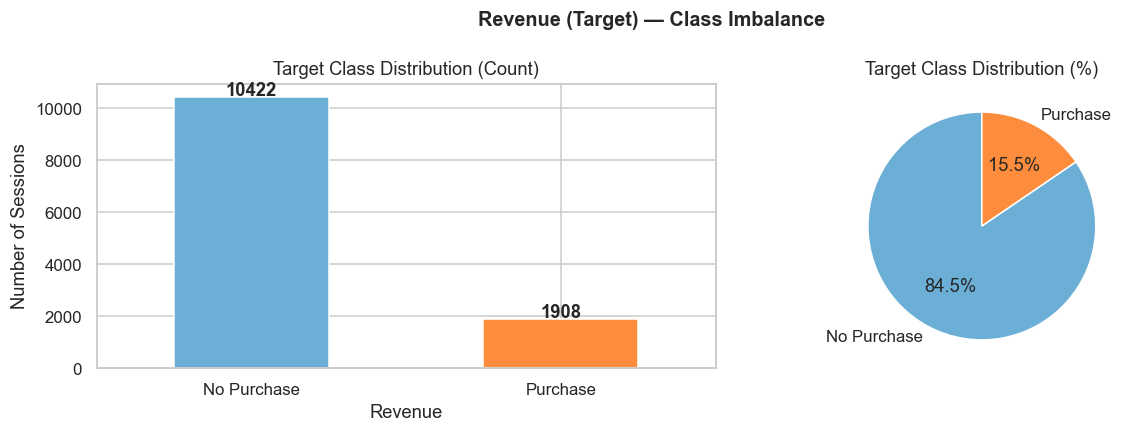

In [9]:
# Create side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: Bar chart with text labels
revenue_counts.plot(kind="bar", ax=axes[0], color=["#6baed6", "#fd8d3c"], rot=0)
axes[0].set(title="Target Class Distribution (Count)", ylabel="Number of Sessions", xticklabels=["No Purchase", "Purchase"])
for i, v in enumerate(revenue_counts):
    axes[0].text(i, v + 50, str(v), ha="center", weight="bold")

# Right: Pie chart
revenue_counts.plot(kind="pie", ax=axes[1], labels=["No Purchase", "Purchase"], autopct="%1.1f%%", colors=["#6baed6", "#fd8d3c"], startangle=90, wedgeprops={"edgecolor": "white"})
axes[1].set(title="Target Class Distribution (%)", ylabel="")

plt.suptitle("Revenue (Target) — Class Imbalance", fontsize=13, weight="bold")
plt.tight_layout()
plt.show()

#### Numerical feature distribution

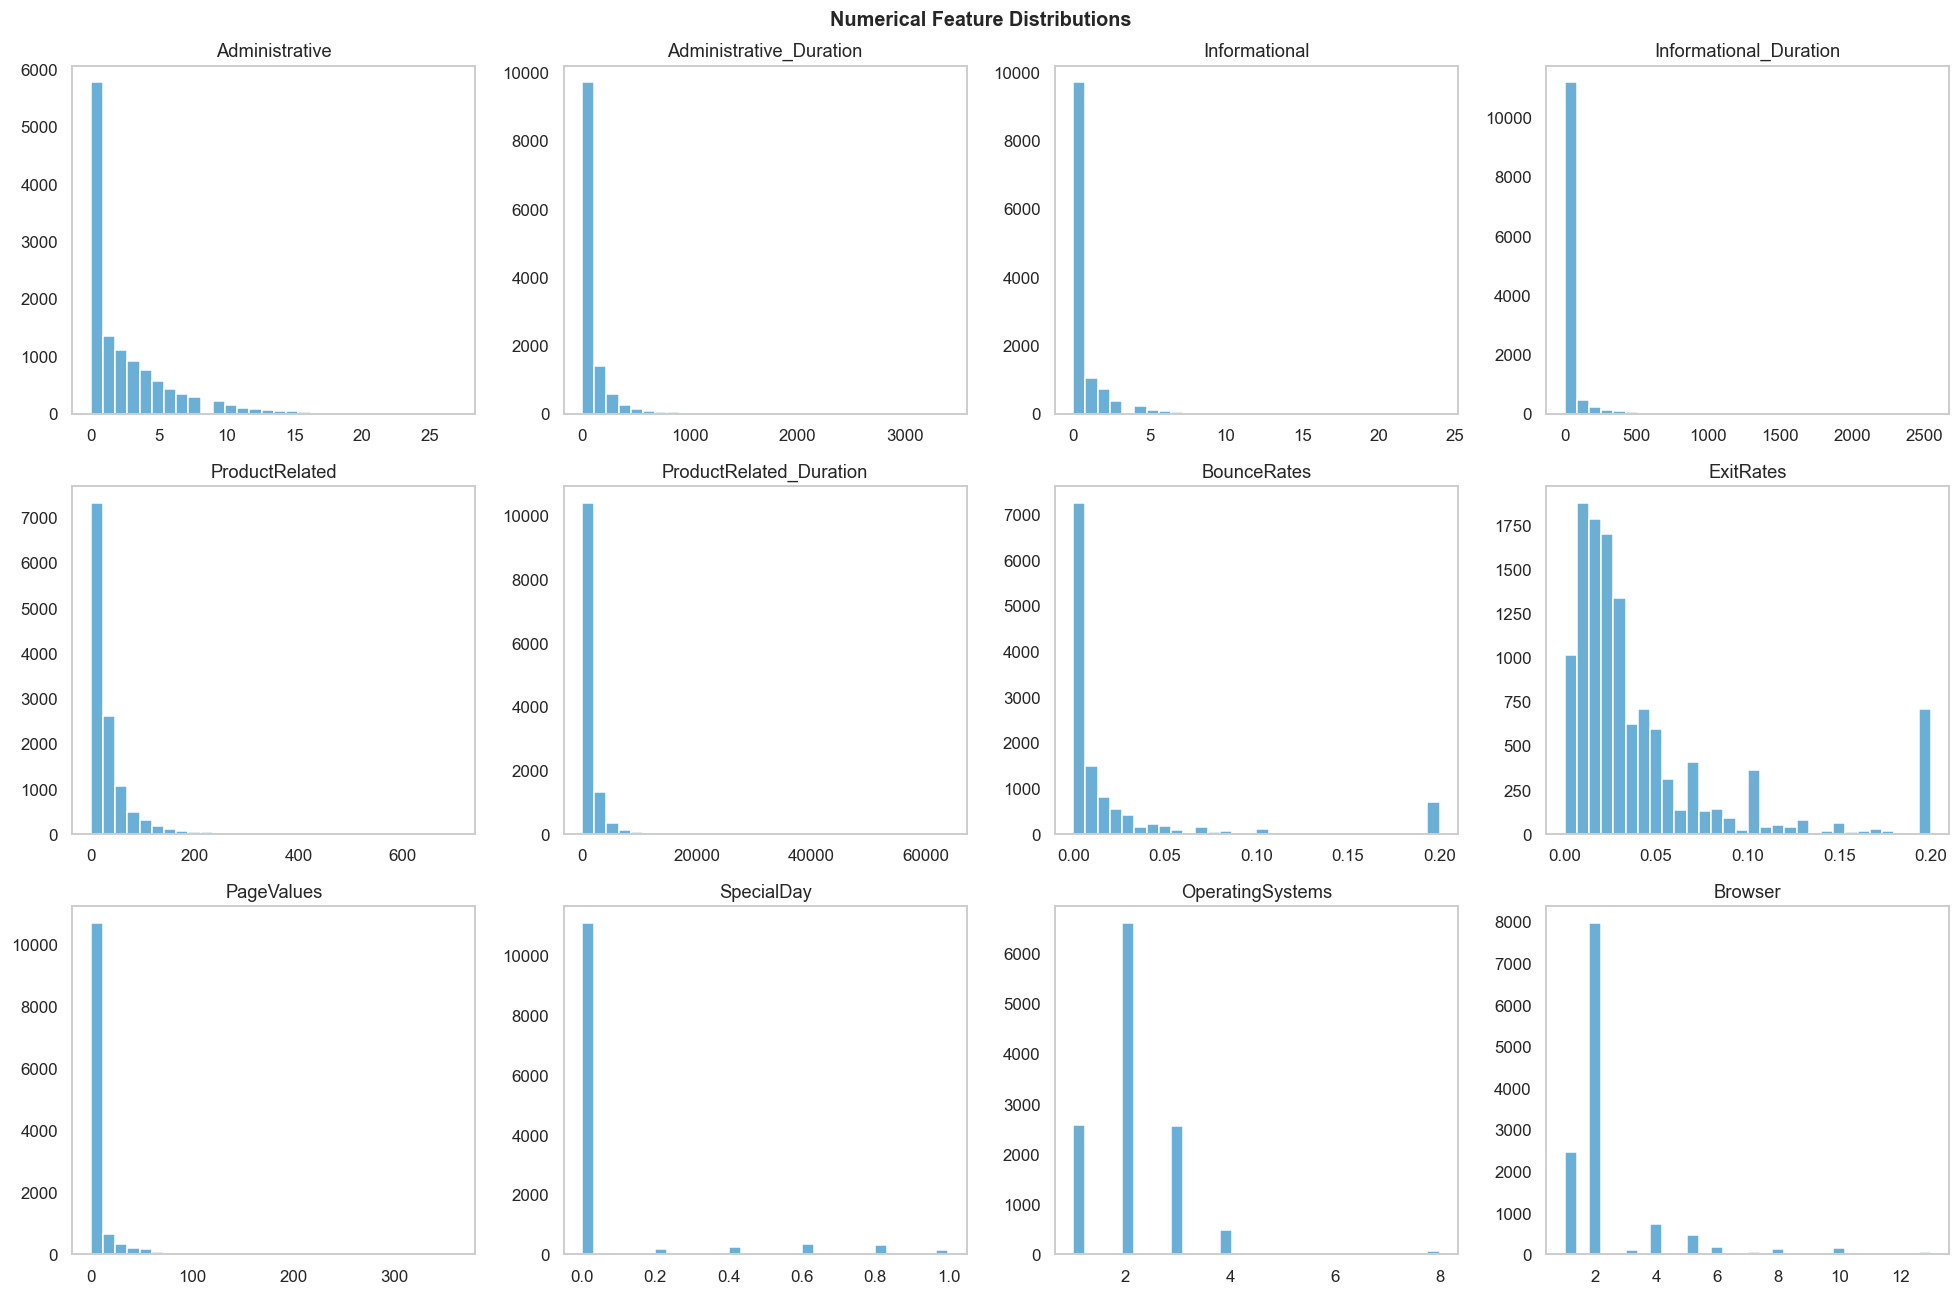

In [10]:
# Select numerical columns except Revenue
num_cols = df.select_dtypes(include="number").drop(columns=["Revenue"], errors="ignore").columns[:12]

# Plot all histograms at once using Pandas
axes = df[num_cols].hist(bins=30, color="#6baed6", edgecolor="white", grid=False, layout=(3, 4), figsize=(18, 12))

# Add main title and clean layout
plt.suptitle("Numerical Feature Distributions", fontsize=13, weight="bold")
plt.tight_layout()
plt.show()

### Dropping the useless columns

In [11]:
X = df.drop(columns=["Revenue"])
y = df["Revenue"].astype(int)

In [12]:
num_features = X.select_dtypes(include=["int64", "float64"]).columns
cat_features = X.select_dtypes(include=["object", "category"]).columns
